# Week 4 - Machine Learning Project

## Artificial Intelligence Internship

### Tasks Covered

1. Machine Learning Algorithms
2. Classification Models
3. Regression Model
4. Model Evaluation and Comparison
5. Mini Project - ML Model Comparison

**Dataset Sources:**
- Iris Dataset: Scikit-learn
- California Housing Dataset: Scikit-learn

**Tools and Technologies:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


# Task 2 - Build Classification Models

## Objective

The objective of this task is to build and compare at least two classification models using a real dataset.

### Dataset Selected

The Iris dataset is used for this classification task. It contains measurements of iris flowers and their corresponding species.

### Models Selected

1. Logistic Regression
2. Decision Tree Classifier

### Workflow

1. Load the dataset
2. Explore the dataset
3. Clean the data
4. Select features and target
5. Split the data into training and testing sets
6. Train the classification models
7. Make predictions
8. Evaluate the models

In [2]:
# Load the Iris dataset
iris = load_iris()

# Convert the dataset into a DataFrame
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
iris_df["target"] = iris.target

# Display the first five rows
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2.1 Dataset Exploration

The Iris dataset contains four numerical features describing the dimensions of iris flowers. The target variable represents three different iris species.

In [3]:
# Display dataset shape
print("Dataset Shape:", iris_df.shape)

# Display column names
print("\nColumns:")
print(iris_df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
iris_df.info()

# Check for missing values
print("\nMissing Values:")
print(iris_df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
iris_df.describe()

Dataset Shape: (150, 5)

Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check the number of samples in each class
print(iris_df["target"].value_counts())

# Display class names
print("\nTarget Classes:")
for i, name in enumerate(iris.target_names):
    print(i, "=", name)

target
0    50
1    50
2    50
Name: count, dtype: int64

Target Classes:
0 = setosa
1 = versicolor
2 = virginica


## 2.2 Data Cleaning

Before training the models, the dataset is checked for missing values and duplicate records. The Iris dataset is already clean, but these checks are performed to ensure data quality.

In [5]:
# Check for missing values
print("Missing values before cleaning:")
print(iris_df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(iris_df.duplicated().sum())

Missing values before cleaning:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Number of duplicate rows:
1


## 2.3 Feature Selection

The four flower measurements are selected as input features:

- Sepal length
- Sepal width
- Petal length
- Petal width

The target variable represents the iris flower species.

In [6]:
# Select features
X = iris_df[iris.feature_names]

# Select target
y = iris_df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


## 2.4 Train-Test Split

The dataset is divided into training and testing sets. 80% of the data is used for training the models, while 20% is reserved for testing their performance.

A fixed random state is used so that the results are reproducible.

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 2.5 Model 1 - Logistic Regression

Logistic Regression is selected as the first classification model because it is simple, efficient, and well suited for multi-class classification problems such as the Iris dataset.

In [8]:
# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Display predictions
print("Logistic Regression Predictions:")
print(y_pred_logistic)

Logistic Regression Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


## 2.6 Model 2 - Decision Tree Classifier

Decision Tree Classifier is selected as the second model because it can capture non-linear relationships between features and classes and does not require feature scaling.

In [10]:
# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [11]:
# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Display predictions
print("Decision Tree Predictions:")
print(y_pred_tree)

Decision Tree Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


## 2.7 Actual vs Predicted Values

The predictions generated by both classification models are compared with the actual target values from the testing dataset.

In [12]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree
})

comparison_df

,Actual,Logistic Regression,Decision Tree
0,0,0,0
1,2,2,2
2,1,1,1
3,1,1,1
4,0,0,0
5,1,1,1
6,0,0,0
7,0,0,0
8,2,2,2
9,1,1,1


## 2.8 Iris Dataset Visualization

The following scatter plot shows the relationship between petal length and petal width for the three iris species.

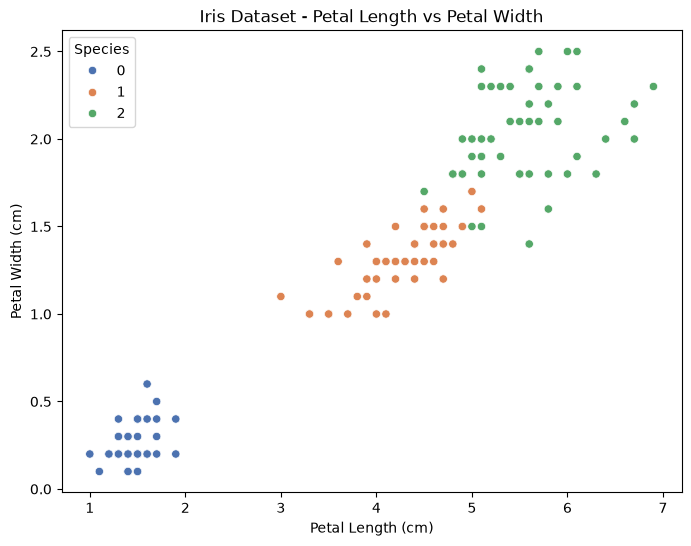

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=iris_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="target",
    palette="deep"
)

plt.title("Iris Dataset - Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")

plt.show()

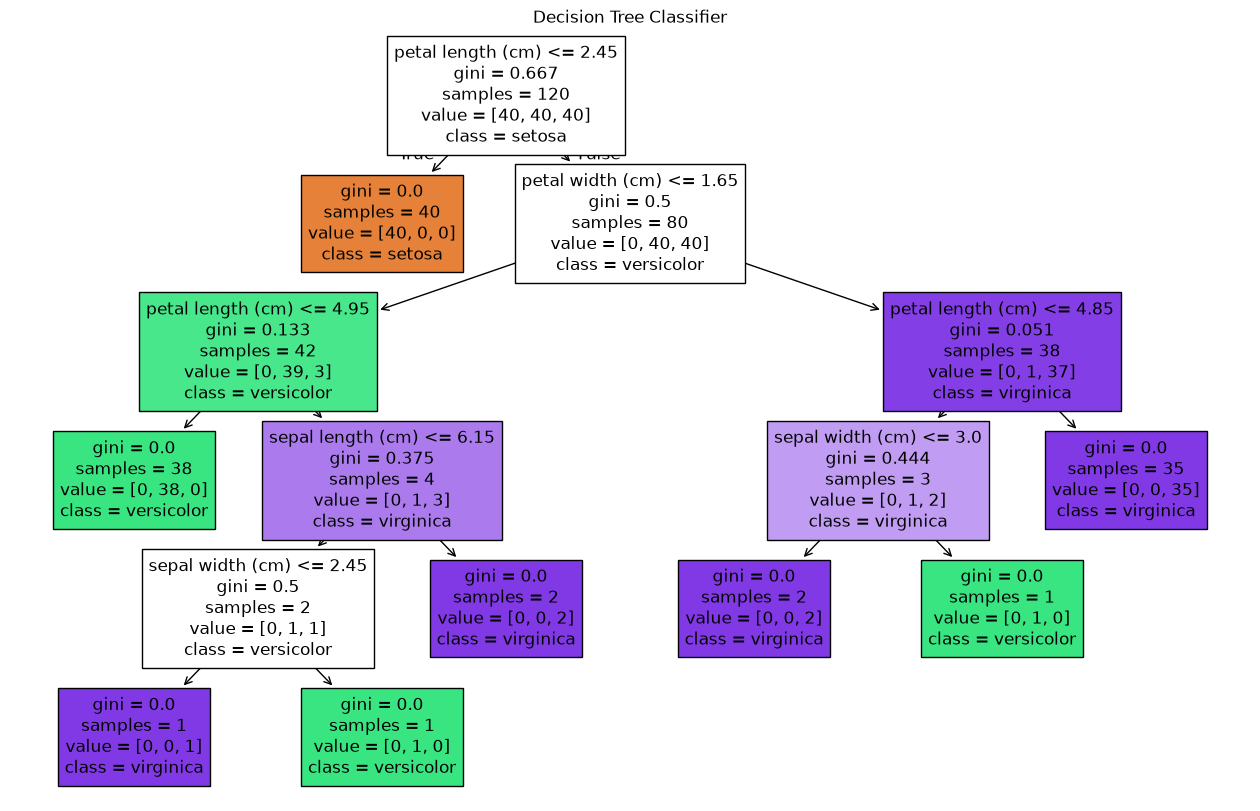

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))

plot_tree(
    decision_tree_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

# Task 3 - Build a Regression Model

## Student Marks Prediction

### Objective

The objective of this task is to build a Linear Regression model that predicts students' marks based on the number of hours they study.

### Dataset Selected

A Student Marks dataset is used for this regression task. The dataset contains the number of hours studied by students and their corresponding marks obtained.

### Feature

- Hours Studied

### Target

- Marks Obtained

### Model Selected

Linear Regression

In [17]:
# Load Student Marks dataset
marks_df = pd.read_csv("Dataset/Student_Marks.csv")

# Display first five rows
marks_df.head()

,Hours_Studied,Marks_Obtained
0,1,35
1,2,40
2,3,45
3,4,50
4,5,55


## 3.1 Dataset Exploration

The dataset contains two numerical variables: Hours Studied and Marks Obtained. The goal is to determine whether the number of hours studied can be used to predict students' marks.

In [18]:
# Display dataset shape
print("Dataset Shape:", marks_df.shape)

# Display column names
print("\nColumns:")
print(marks_df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
marks_df.info()

# Display statistical summary
print("\nStatistical Summary:")
marks_df.describe()

Dataset Shape: (57, 2)

Columns:
['Hours_Studied', 'Marks_Obtained']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Hours_Studied   57 non-null     int64
 1   Marks_Obtained  57 non-null     int64
dtypes: int64(2)
memory usage: 1.0 KB

Statistical Summary:


,Hours_Studied,Marks_Obtained
count,57.000000,57.000000
mean,8.350877,71.491228
std,4.181128,20.108743
min,1.000000,32.000000
25%,5.000000,55.000000
50%,8.000000,72.000000
75%,12.000000,90.000000
max,15.000000,100.000000


## 3.2 Data Cleaning

The dataset is checked for missing values and duplicate records before training the model.

In [19]:
# Check for missing values
print("Missing Values:")
print(marks_df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:")
print(marks_df.duplicated().sum())

Missing Values:
Hours_Studied     0
Marks_Obtained    0
dtype: int64

Duplicate Rows:
3


## 3.3 Feature Selection

Hours Studied is selected as the input feature because the objective is to predict Marks Obtained based on the number of hours a student studies.

Marks Obtained is selected as the target variable.

In [20]:
# Select feature and target
X_reg = marks_df[["Hours_Studied"]]
y_reg = marks_df["Marks_Obtained"]

print("Feature shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

Feature shape: (57, 1)
Target shape: (57,)


## 3.4 Train-Test Split

The dataset is divided into training and testing sets. 80% of the data is used for training the Linear Regression model and 20% is used for testing its performance.

In [21]:
# Split the dataset
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train_reg.shape[0])
print("Testing samples:", X_test_reg.shape[0])

Training samples: 45
Testing samples: 12


## 3.5 Linear Regression Model

Linear Regression is used to model the relationship between hours studied and marks obtained. The model attempts to find the best-fitting straight line through the training data.

In [22]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_reg, y_train_reg)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 3.6 Make Predictions

The trained model is used to predict marks for the testing dataset.

In [23]:
# Make predictions
y_pred_reg = linear_model.predict(X_test_reg)

print("Predicted Marks:")
print(y_pred_reg)

Predicted Marks:
[36.90347924 60.5342312  41.62962963 98.34343434 60.5342312  88.89113356
 98.34343434 46.35578002 55.80808081 93.61728395 74.71268238 51.08193042]


## 3.7 Actual vs Predicted Values

The actual marks are compared with the marks predicted by the Linear Regression model.

In [24]:
# Create comparison table
regression_comparison = pd.DataFrame({
    "Hours Studied": X_test_reg["Hours_Studied"].values,
    "Actual Marks": y_test_reg.values,
    "Predicted Marks": y_pred_reg
})

regression_comparison = regression_comparison.sort_values(
    by="Hours Studied"
)

regression_comparison

,Hours Studied,Actual Marks,Predicted Marks
0,1,35,36.903479
2,2,38,41.629630
7,3,44,46.355780
11,4,50,51.081930
8,5,56,55.808081
1,6,60,60.534231
4,6,59,60.534231
10,9,77,74.712682
5,12,91,88.891134
9,13,95,93.617284


## 3.8 Regression Visualization

The scatter plot shows the actual student marks, while the regression line represents the marks predicted by the Linear Regression model.

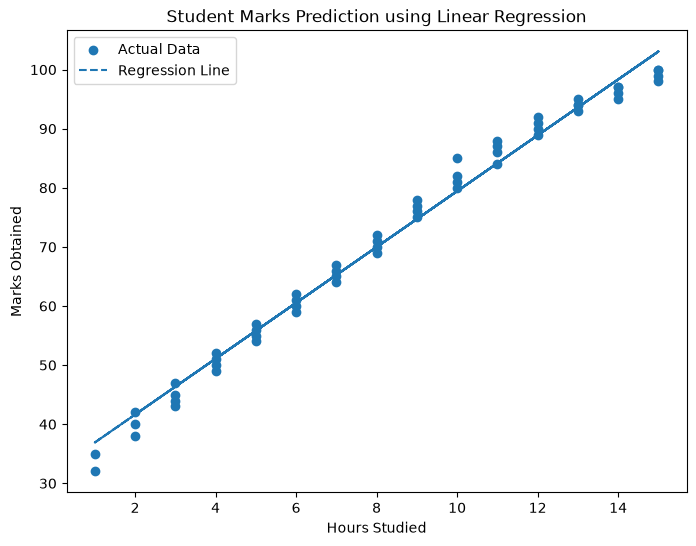

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_reg["Hours_Studied"],
    y_reg,
    label="Actual Data"
)

plt.plot(
    X_reg["Hours_Studied"],
    linear_model.predict(X_reg),
    linestyle="--",
    label="Regression Line"
)

plt.title("Student Marks Prediction using Linear Regression")
plt.xlabel("Hours Studied")
plt.ylabel("Marks Obtained")
plt.legend()

plt.show()

# Task 4 - Model Evaluation & Comparison

## Objective

The objective of this task is to evaluate the classification and regression models created in Tasks 2 and 3.

### Classification Metrics

The classification models are evaluated using:

- Accuracy
- Precision
- Recall
- Confusion Matrix

### Regression Metrics

The Linear Regression model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The results are then compared to determine the best-performing models.

## 4.1 Logistic Regression Evaluation

In [37]:
# Calculate Logistic Regression metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Logistic Regression")
print("-------------------")
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")

Logistic Regression
-------------------
Accuracy:  0.9667
Precision: 0.9697
Recall:    0.9667


In [38]:
# Calculate confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


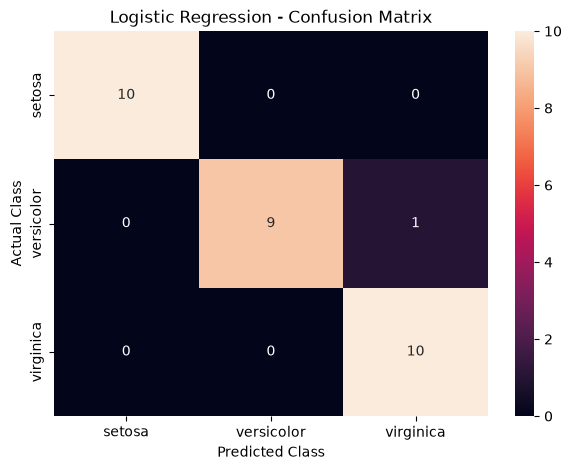

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## 4.2 Decision Tree Evaluation

In [40]:
# Calculate Decision Tree metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

print("Decision Tree")
print("-------------")
print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")

Decision Tree
-------------
Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333


In [41]:
# Calculate confusion matrix
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


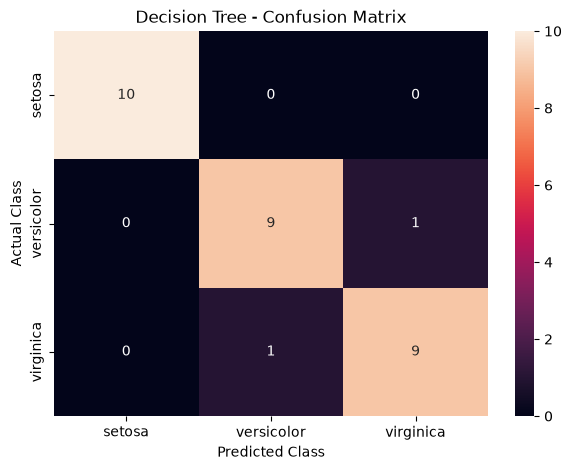

In [42]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## 4.3 Classification Model Comparison

In [43]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall
    ]
})

classification_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.966667,0.969697,0.966667
1,Decision Tree,0.933333,0.933333,0.933333


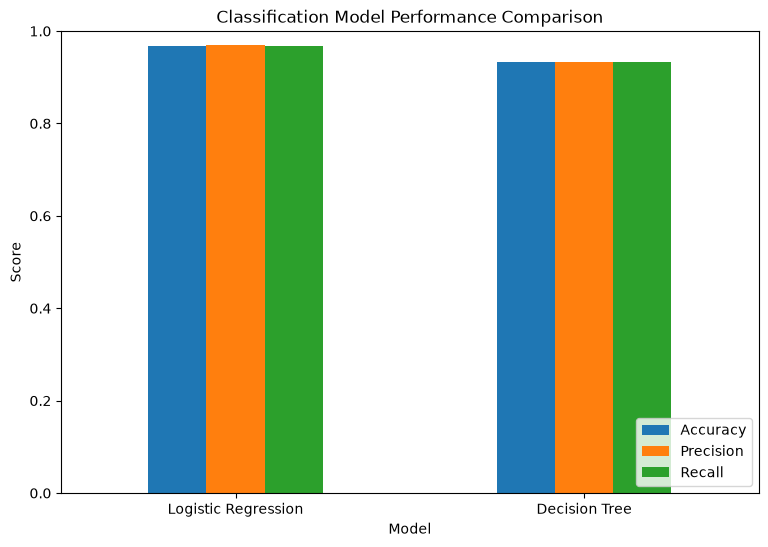

In [44]:
classification_plot = classification_comparison.set_index("Model")

classification_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

## 4.4 Linear Regression Evaluation

The Linear Regression model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [45]:
# Calculate regression metrics

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("Linear Regression")
print("------------------")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Linear Regression
------------------
MAE:  1.7247
MSE:  3.7568
RMSE: 1.9382
R²:   0.9926


## 4.5 Regression Evaluation Table

In [46]:
regression_metrics = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse],
    "R2 Score": [r2]
})

regression_metrics

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.724747,3.75678,1.938242,0.992628


## 4.6 Overall Model Comparison

The classification models and regression model solve different types of problems. Therefore, their performance metrics are evaluated separately.

For classification, higher Accuracy, Precision, and Recall indicate better performance.

For regression, lower MAE, MSE, and RMSE and higher R² indicate better performance.

In [47]:
# Determine the better classification model based on accuracy

if logistic_accuracy > tree_accuracy:
    best_classification_model = "Logistic Regression"
elif tree_accuracy > logistic_accuracy:
    best_classification_model = "Decision Tree"
else:
    best_classification_model = "Both models have equal accuracy"

print("Best Classification Model:", best_classification_model)

Best Classification Model: Logistic Regression


## 4.7 Task 4 Conclusion

The classification models were evaluated using Accuracy, Precision, Recall, and Confusion Matrix. The regression model was evaluated using MAE, MSE, RMSE, and R² Score.

The classification comparison shows which of Logistic Regression and Decision Tree performed better on the Iris dataset. The better model is selected based primarily on its predictive performance on the test dataset.

The Linear Regression model is evaluated separately because it solves a regression problem rather than a classification problem. Its performance is determined by the size of its prediction errors and its R² Score.

Model selection should not depend only on a single metric. Factors such as interpretability, computational requirements, dataset characteristics, overfitting, and the requirements of the real-world application should also be considered.

# Task 5 - Mini Project

# Breast Cancer Classification

## 5.1 Problem Definition

Breast cancer is one of the most common types of cancer. Early and accurate classification of breast tumors can assist medical professionals in identifying whether a tumor is likely to be malignant or benign.

In this mini project, Machine Learning classification models are used to predict whether a breast tumor is malignant or benign based on numerical measurements obtained from breast cancer diagnostic data.

The objective is to build and compare two classification models and determine which model provides better predictive performance.

### Models Selected

1. Logistic Regression
2. Decision Tree Classifier

### Project Workflow

Problem Definition → Dataset → Data Cleaning → Data Analysis → Feature Selection → Train/Test Split → Model 1 → Model 2 → Prediction → Evaluation → Comparison → Conclusion

In [48]:
# Import the Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

print("Breast Cancer dataset loaded successfully!")

Breast Cancer dataset loaded successfully!


In [49]:
# Convert dataset into a DataFrame
cancer_df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Add target column
cancer_df["target"] = breast_cancer.target

# Display first five rows
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 5.2 Dataset Description

The Breast Cancer Wisconsin Diagnostic dataset available through Scikit-learn is used for this project.

The dataset contains numerical measurements computed from digitized images of breast mass samples. These measurements describe characteristics such as radius, texture, perimeter, area, smoothness, and other properties of the cell nuclei.

The target variable represents two classes:

- 0 - Malignant
- 1 - Benign

The dataset contains 569 observations and 30 numerical input features.

## 5.3 Data Analysis

In [50]:
# Display dataset shape
print("Dataset Shape:", cancer_df.shape)

# Display column names
print("\nNumber of Features:", len(breast_cancer.feature_names))

# Display target classes
print("\nTarget Classes:")
print(breast_cancer.target_names)

# Display statistical summary
print("\nStatistical Summary:")
cancer_df.describe()

Dataset Shape: (569, 31)

Number of Features: 30

Target Classes:
['malignant' 'benign']

Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [51]:
# Check for missing values
print("Missing Values:")
print(cancer_df.isnull().sum().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(cancer_df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
0


## 5.4 Target Distribution

The distribution of malignant and benign samples is examined to understand the balance of the target classes.

target
1    357
0    212
Name: count, dtype: int64


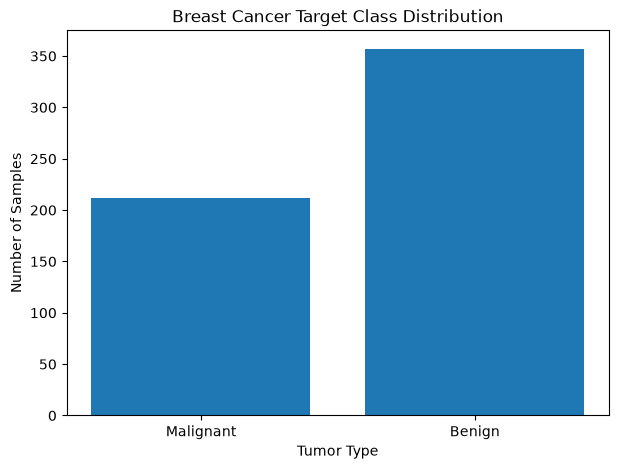

In [53]:
# Count target classes
target_counts = cancer_df["target"].value_counts()

print(target_counts)

# Plot target distribution
plt.figure(figsize=(7, 5))

plt.bar(
    ["Malignant", "Benign"],
    target_counts.sort_index()
)

plt.title("Breast Cancer Target Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Samples")

plt.show()

## 5.5 Feature Selection

All 30 numerical diagnostic features are selected as input variables because each feature provides information about characteristics of the tumor.

The target variable is used to represent whether the tumor is malignant or benign.

In [54]:
# Select features and target
X_cancer = cancer_df[breast_cancer.feature_names]
y_cancer = cancer_df["target"]

print("Feature Shape:", X_cancer.shape)
print("Target Shape:", y_cancer.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


## 5.6 Train-Test Split

The dataset is divided into training and testing sets. 80% of the observations are used for training and 20% are used for testing.

A fixed random state is used so that the results can be reproduced.

In [55]:
# Split the dataset
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=42,
    stratify=y_cancer
)

print("Training samples:", X_train_cancer.shape[0])
print("Testing samples:", X_test_cancer.shape[0])

Training samples: 455
Testing samples: 114


## 5.7 Model 1 - Logistic Regression

Logistic Regression is used as the first classification model. It estimates the probability that an observation belongs to a particular class and is suitable for binary classification problems such as malignant versus benign tumor classification.

In [56]:
# Create Logistic Regression model
cancer_logistic = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Train the model
cancer_logistic.fit(
    X_train_cancer,
    y_train_cancer
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [57]:
# Make predictions
cancer_pred_logistic = cancer_logistic.predict(
    X_test_cancer
)

print("Logistic Regression predictions:")
print(cancer_pred_logistic[:20])

Logistic Regression predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


## 5.8 Model 2 - Decision Tree Classifier

A Decision Tree Classifier is used as the second model. The algorithm makes predictions by creating a tree-like structure of decision rules based on the input features.

In [58]:
# Create Decision Tree model
cancer_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
cancer_tree.fit(
    X_train_cancer,
    y_train_cancer
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [59]:
# Make predictions
cancer_pred_tree = cancer_tree.predict(
    X_test_cancer
)

print("Decision Tree predictions:")
print(cancer_pred_tree[:20])

Decision Tree predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


## 5.9 Model Evaluation

Both classification models are evaluated using Accuracy, Precision, Recall, and Confusion Matrix.

Higher values of Accuracy, Precision, and Recall indicate better classification performance.

In [60]:
# Logistic Regression metrics
cancer_logistic_accuracy = accuracy_score(
    y_test_cancer,
    cancer_pred_logistic
)

cancer_logistic_precision = precision_score(
    y_test_cancer,
    cancer_pred_logistic
)

cancer_logistic_recall = recall_score(
    y_test_cancer,
    cancer_pred_logistic
)

# Decision Tree metrics
cancer_tree_accuracy = accuracy_score(
    y_test_cancer,
    cancer_pred_tree
)

cancer_tree_precision = precision_score(
    y_test_cancer,
    cancer_pred_tree
)

cancer_tree_recall = recall_score(
    y_test_cancer,
    cancer_pred_tree
)

print("Logistic Regression")
print("-------------------")
print(f"Accuracy:  {cancer_logistic_accuracy:.4f}")
print(f"Precision: {cancer_logistic_precision:.4f}")
print(f"Recall:    {cancer_logistic_recall:.4f}")

print("\nDecision Tree")
print("-------------")
print(f"Accuracy:  {cancer_tree_accuracy:.4f}")
print(f"Precision: {cancer_tree_precision:.4f}")
print(f"Recall:    {cancer_tree_recall:.4f}")

Logistic Regression
-------------------
Accuracy:  0.9649
Precision: 0.9595
Recall:    0.9861

Decision Tree
-------------
Accuracy:  0.9211
Precision: 0.9565
Recall:    0.9167


## 5.10 Model Comparison

In [61]:
# Create model comparison table
cancer_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        cancer_logistic_accuracy,
        cancer_tree_accuracy
    ],
    "Precision": [
        cancer_logistic_precision,
        cancer_tree_precision
    ],
    "Recall": [
        cancer_logistic_recall,
        cancer_tree_recall
    ]
})

cancer_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.964912,0.959459,0.986111
1,Decision Tree,0.921053,0.956522,0.916667


In [62]:
# Logistic Regression confusion matrix
cancer_logistic_cm = confusion_matrix(
    y_test_cancer,
    cancer_pred_logistic
)

print("Logistic Regression Confusion Matrix:")
print(cancer_logistic_cm)

Logistic Regression Confusion Matrix:
[[39  3]
 [ 1 71]]


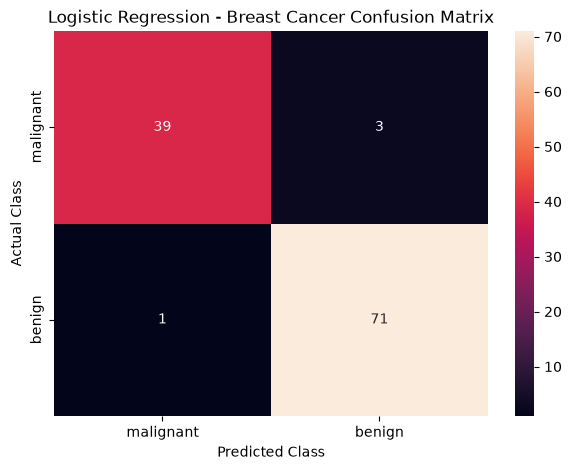

In [63]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cancer_logistic_cm,
    annot=True,
    fmt="d",
    xticklabels=breast_cancer.target_names,
    yticklabels=breast_cancer.target_names
)

plt.title("Logistic Regression - Breast Cancer Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [64]:
# Decision Tree confusion matrix
cancer_tree_cm = confusion_matrix(
    y_test_cancer,
    cancer_pred_tree
)

print("Decision Tree Confusion Matrix:")
print(cancer_tree_cm)

Decision Tree Confusion Matrix:
[[39  3]
 [ 6 66]]


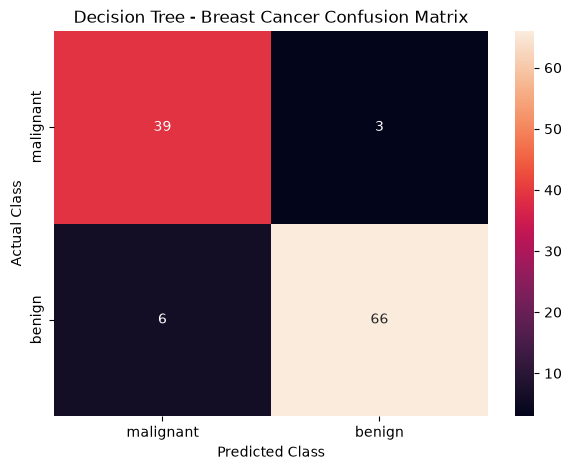

In [65]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cancer_tree_cm,
    annot=True,
    fmt="d",
    xticklabels=breast_cancer.target_names,
    yticklabels=breast_cancer.target_names
)

plt.title("Decision Tree - Breast Cancer Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## 5.11 Model Performance Visualization

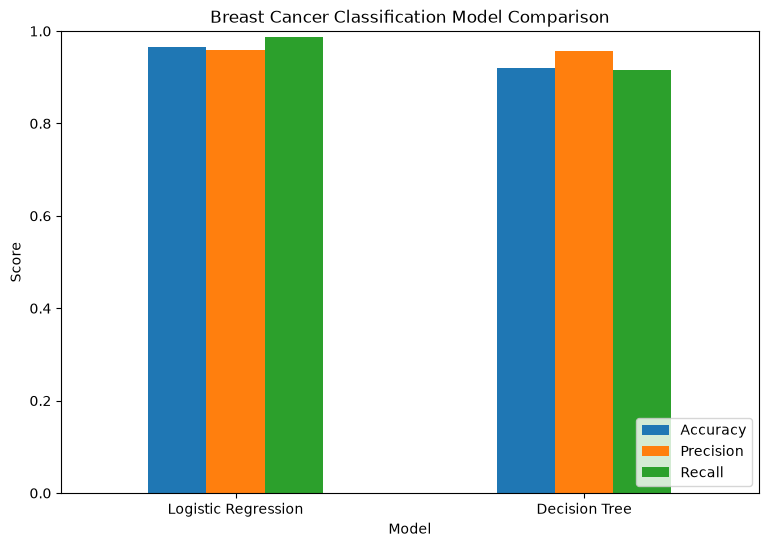

In [66]:
# Plot model performance comparison

comparison_plot = cancer_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Breast Cancer Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [68]:
# Determine the best model based on accuracy

if cancer_logistic_accuracy > cancer_tree_accuracy:
    best_cancer_model = "Logistic Regression"
elif cancer_tree_accuracy > cancer_logistic_accuracy:
    best_cancer_model = "Decision Tree"
else:
    best_cancer_model = "Both models have equal accuracy"

print("Best-performing model:", best_cancer_model)

Best-performing model: Logistic Regression


## 5.12 Feature Importance

The Decision Tree model provides feature importance values that indicate how useful each feature was in making classification decisions.

In [69]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": breast_cancer.feature_names,
    "Importance": cancer_tree.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
20,worst radius,0.714332
27,worst concave points,0.118831
11,texture error,0.053907
21,worst texture,0.031473
26,worst concavity,0.016712
24,worst smoothness,0.012978
13,area error,0.012371
1,mean texture,0.011536
28,worst symmetry,0.010987
23,worst area,0.008652


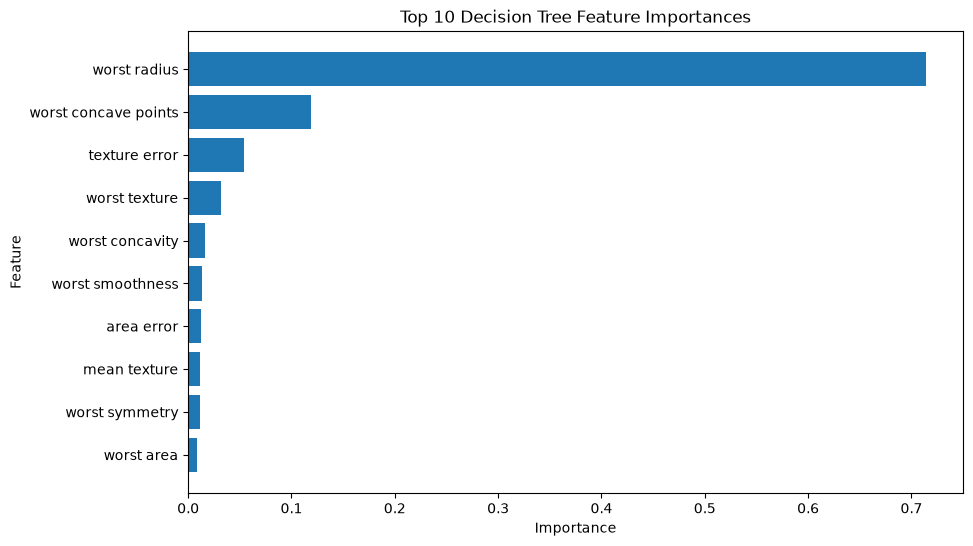

In [70]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## 5.13 Mini Project Conclusion

Two Machine Learning classification models, Logistic Regression and Decision Tree Classifier, were developed to classify breast tumors as malignant or benign.

The models were trained using 80% of the dataset and evaluated using the remaining 20%. Accuracy, Precision, Recall, and Confusion Matrix were used to assess their performance.

The model comparison helps identify which algorithm performs better on the selected dataset. The better-performing model can be selected based on its test-set performance while also considering interpretability and computational requirements.

The Decision Tree model additionally provides feature importance values, which can help understand which diagnostic measurements contributed most to its predictions.

The results demonstrate how Machine Learning classification algorithms can be applied to a real-world medical classification problem.

## 5.14 Final Results

The comparison of the two classification models showed that **Logistic Regression** was the best-performing model for the Breast Cancer Classification problem.

Logistic Regression achieved higher overall test-set performance than the Decision Tree Classifier based on the evaluation metrics used in this project.

Therefore, Logistic Regression is selected as the preferred model for this dataset.

The Decision Tree model remains useful because it provides feature importance information and is easier to interpret as a set of decision rules.

In [71]:
# Final Mini Project Results

print("FINAL MODEL COMPARISON")
print("=" * 40)

print(cancer_comparison.to_string(index=False))

print("\nBest-performing model:", best_cancer_model)

FINAL MODEL COMPARISON
              Model  Accuracy  Precision   Recall
Logistic Regression  0.964912   0.959459 0.986111
      Decision Tree  0.921053   0.956522 0.916667

Best-performing model: Logistic Regression


# Mini Project Report - Breast Cancer Classification

## Problem Statement

Breast cancer is a major health concern, and accurate classification of tumors can assist in identifying whether a tumor is malignant or benign. The objective of this project is to use Machine Learning classification algorithms to predict the type of breast tumor from numerical diagnostic measurements.

## Dataset Used

The Breast Cancer Wisconsin Diagnostic dataset available through Scikit-learn was used. It contains 569 observations and 30 numerical features describing characteristics of cell nuclei, including radius, texture, perimeter, area, smoothness, and other measurements. The target variable contains two classes: malignant and benign.

## Data Preprocessing and Feature Selection

The dataset was checked for missing values and duplicate records. No missing values were found. All 30 numerical diagnostic features were selected as input variables. The target variable was used for classification. The dataset was divided into 80% training data and 20% testing data using a fixed random state and stratified sampling.

## Models Selected

Two classification algorithms were developed: Logistic Regression and Decision Tree Classifier. Logistic Regression was selected as a baseline classification model, while Decision Tree was selected because of its interpretability and ability to represent decisions through a tree structure.

## Results

Logistic Regression achieved an accuracy of 96.49%, precision of 95.95%, and recall of 98.61%. The Decision Tree achieved an accuracy of 92.11%, precision of 95.65%, and recall of 91.67%. Based on the evaluation results, Logistic Regression performed better overall.

## Conclusion

Logistic Regression was selected as the best-performing model for this dataset because it achieved higher accuracy and recall than the Decision Tree model. However, the results are based on a single dataset and train-test split. Future improvements could include cross-validation, hyperparameter tuning, feature scaling and selection, and testing additional classification algorithms.

## Limitations

The model should not be considered a replacement for professional medical diagnosis. Its predictions depend on the quality and characteristics of the training data. Further validation on independent clinical datasets would be required before considering practical deployment.